In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("us_perm_visas.csv")

C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_29912\1541961394.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,10,11,16,17,20,21,22,25,26,27,28,29,30,31,32,33,34,35,36,37,39,40,41,42,43,44,45,47,48,49,50,51,52,53,55,56,57,58,59,60,61,63,64,65,66,68,69,70,71,72,73,74,77,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,100,101,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,153) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("us_perm_visas.csv")


In [3]:
df

,add_these_pw_job_title_9089,agent_city,agent_firm_name,agent_state,application_type,case_no,case_number,case_received_date,case_status,class_of_admission,...,ri_pvt_employment_firm_to,ri_us_workers_considered,schd_a_sheepherder,us_economic_sector,wage_offer_from_9089,wage_offer_to_9089,wage_offer_unit_of_pay_9089,wage_offered_from_9089,wage_offered_to_9089,wage_offered_unit_of_pay_9089
0,NaN,NaN,NaN,NaN,PERM,A-07323-97014,NaN,NaN,Certified,J-1,...,NaN,NaN,NaN,IT,75629.0,NaN,yr,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,PERM,A-07332-99439,NaN,NaN,Denied,B-2,...,NaN,NaN,NaN,Other Economic Sector,37024.0,NaN,yr,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,PERM,A-07333-99643,NaN,NaN,Certified,H-1B,...,NaN,NaN,NaN,Aerospace,47923.0,NaN,yr,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,PERM,A-07339-01930,NaN,NaN,Certified,B-2,...,NaN,NaN,NaN,Other Economic Sector,10.97,NaN,hr,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,PERM,A-07345-03565,NaN,NaN,Certified,L-1,...,NaN,NaN,NaN,Advanced Mfg,100000.0,NaN,yr,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374357,NaN,Buena Park,Law Offices of Yohan Lee,CA,NaN,NaN,A-16363-85407,2016-12-29,Withdrawn,NaN,...,NaN,NaN,N,NaN,"28,330.00",NaN,Year,NaN,NaN,NaN
374358,NaN,Seattle,MacDonald Hoague & Bayless,WA,NaN,NaN,A-16271-56745,2016-12-30,Withdrawn,L-1,...,NaN,Y,N,NaN,"122,000.00","142,000.00",Year,NaN,NaN,NaN
374359,NaN,Schaumburg,International Legal and Business Services Grou...,IL,NaN,NaN,A-16354-82345,2016-12-30,Withdrawn,H-1B,...,NaN,NaN,N,NaN,"79,082.00","79,082.00",Year,NaN,NaN,NaN
374360,NaN,LOS ANGELES,LAW OFFICES OF JAMES S HONG,CA,NaN,NaN,A-16357-84250,2016-12-30,Withdrawn,B-2,...,NaN,NaN,N,NaN,"37,981.00",NaN,Year,NaN,NaN,NaN


In [9]:
print(df.columns.values)

['add_these_pw_job_title_9089' 'agent_city' 'agent_firm_name'
 'agent_state' 'application_type' 'case_no' 'case_number'
 'case_received_date' 'case_status' 'class_of_admission'
 'country_of_citizenship' 'country_of_citzenship' 'decision_date'
 'employer_address_1' 'employer_address_2' 'employer_city'
 'employer_country' 'employer_decl_info_title' 'employer_name'
 'employer_num_employees' 'employer_phone' 'employer_phone_ext'
 'employer_postal_code' 'employer_state' 'employer_yr_estab'
 'foreign_worker_info_alt_edu_experience'
 'foreign_worker_info_birth_country' 'foreign_worker_info_city'
 'foreign_worker_info_education' 'foreign_worker_info_education_other'
 'foreign_worker_info_inst' 'foreign_worker_info_major'
 'foreign_worker_info_postal_code' 'foreign_worker_info_rel_occup_exp'
 'foreign_worker_info_req_experience' 'foreign_worker_info_state'
 'foreign_worker_info_training_comp' 'foreign_worker_ownership_interest'
 'foreign_worker_yr_rel_edu_completed' 'fw_info_alt_edu_experience'

In [12]:
df['case_no'].nunique()

134990

In [14]:
df['case_number'].nunique()

238418

In [18]:
df['case_no']

0         A-07323-97014
1         A-07332-99439
2         A-07333-99643
3         A-07339-01930
4         A-07345-03565
              ...      
374357              NaN
374358              NaN
374359              NaN
374360              NaN
374361              NaN
Name: case_no, Length: 374362, dtype: object

In [17]:
df.isnull().sum()

add_these_pw_job_title_9089      332168
agent_city                       162908
agent_firm_name                  167365
agent_state                      166123
application_type                 239093
                                  ...  
wage_offer_to_9089               300728
wage_offer_unit_of_pay_9089      115916
wage_offered_from_9089           259715
wage_offered_to_9089             343347
wage_offered_unit_of_pay_9089    303663
Length: 154, dtype: int64

In [ ]:
#df['case_no'].dropna(inplace= True)

In [105]:
casenoindex = df.columns.get_loc("case_no")
casenumberindex = df.columns.get_loc("case_number")
casenumberlist = []

for value in df.iloc[0:135269, casenoindex]:
    casenumberlist.append(value)

for value in df.iloc[135269:374362, casenumberindex]:
    casenumberlist.append(value)

df['casenumberlist'] = casenumberlist

In [106]:
df['casenumberlist'].isnull().sum()

np.int64(0)

In [107]:
df.drop(['case_no','case_number'],axis=1,inplace= True)

In [108]:
df['case_status'].unique()

array(['Certified', 'Denied', 'Certified-Expired', 'Withdrawn'],
      dtype=object)

In [71]:
df['case_status'].value_counts()

case_status
Certified            181933
Certified-Expired    148586
Denied                25649
Withdrawn             18194
Name: count, dtype: int64

In [72]:
for value in df.case_status.unique():
    print(len(df[df['case_status'] == value]),f"occurence of status '{value}'")

181933 occurence of status 'Certified'
25649 occurence of status 'Denied'
148586 occurence of status 'Certified-Expired'
18194 occurence of status 'Withdrawn'


In [109]:
df =df[df.case_status != 'Withdrawn']
#df = df[df["Name"] != "Bob"]

In [110]:
df['case_status'].unique()

array(['Certified', 'Denied', 'Certified-Expired'], dtype=object)

In [75]:
df.shape

(356168, 153)

In [111]:
df.loc[df.case_status == 'Certified-Expired', 'case_status'] = 'Certified'

In [112]:
df['case_status'].value_counts()

case_status
Certified    330519
Denied        25649
Name: count, dtype: int64

In [138]:
df['case_status'] = df['case_status'].str.strip()

In [81]:
df['case_status'].value_counts(normalize=True)*100

case_status
Certified    92.798623
Denied        7.201377
Name: proportion, dtype: float64

In [113]:
df.dropna(axis =1 , how= 'all', inplace = True)

In [114]:
df.dropna(axis =0, how= 'all', inplace = True)

In [92]:
df.isnull().sum()

add_these_pw_job_title_9089      0
agent_city                       0
agent_firm_name                  0
agent_state                      0
application_type                 0
                                ..
wage_offer_unit_of_pay_9089      0
wage_offered_from_9089           0
wage_offered_to_9089             0
wage_offered_unit_of_pay_9089    0
casenumberlist                   0
Length: 153, dtype: int64

In [115]:
for column in df.columns:
    print(f"The missing value for {column} is {df[column].isnull().sum()}")

The missing value for add_these_pw_job_title_9089 is 317031
The missing value for agent_city is 153452
The missing value for agent_firm_name is 157646
The missing value for agent_state is 156544
The missing value for application_type is 229320
The missing value for case_received_date is 126848
The missing value for case_status is 0
The missing value for class_of_admission is 21085
The missing value for country_of_citizenship is 19272
The missing value for country_of_citzenship is 336951
The missing value for decision_date is 0
The missing value for employer_address_1 is 37
The missing value for employer_address_2 is 236133
The missing value for employer_city is 10
The missing value for employer_country is 126920
The missing value for employer_decl_info_title is 126886
The missing value for employer_name is 8
The missing value for employer_num_employees is 126925
The missing value for employer_phone is 126883
The missing value for employer_phone_ext is 333670
The missing value for emplo

In [116]:
#df.dropna(inplace=True)

In [117]:
df['decision_date'] =pd.to_datetime(df['decision_date'])

In [118]:
df['decision_date'].dtypes

dtype('<M8[ns]')

In [119]:
df['year']= df['decision_date'].dt.year
df['month'] = df['decision_date'].dt.month
df['day'] = df['decision_date'].dt.day

In [120]:
df['decision_date']

0        2012-02-01
1        2011-12-21
2        2011-12-01
3        2011-12-01
4        2012-01-26
            ...    
374349   2016-12-30
374350   2016-12-30
374351   2016-12-30
374352   2016-12-30
374353   2016-12-30
Name: decision_date, Length: 356168, dtype: datetime64[ns]

In [128]:
sns.countplot(x = 'year', hue= 'case_status', data =df)

<Axes: xlabel='year', ylabel='count'>

In [130]:
sns.barplot(x = 'year', hue= 'case_status', data =df)

<Axes: xlabel='year', ylabel='count'>

In [131]:
df['case_status']

0         Certified
1            Denied
2         Certified
3         Certified
4         Certified
            ...    
374349    Certified
374350    Certified
374351    Certified
374352    Certified
374353    Certified
Name: case_status, Length: 356168, dtype: object

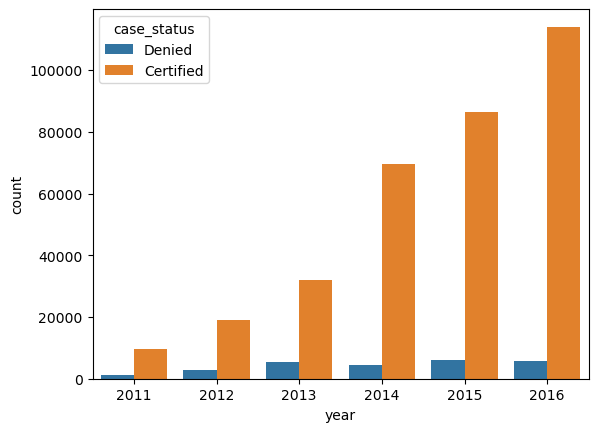

In [149]:
sns.countplot(x = 'year', hue = 'case_status', data = df)
plt.show()

In [148]:
df['case_status'] = df['case_status'].str.strip()

In [150]:
df['employer_city'].value_counts()

employer_city
NEW YORK           15992
COLLEGE STATION    11983
SANTA CLARA        10446
SAN JOSE            9004
REDMOND             8469
                   ...  
Goldsboro              1
Sealy                  1
austin                 1
Carson City            1
TREMONTON              1
Name: count, Length: 8324, dtype: int64

In [151]:
df['employer_city'] = df['employer_city'].str.upper()
df['employer_city'].value_counts()

employer_city
NEW YORK            17198
COLLEGE STATION     11985
SANTA CLARA         10519
SAN JOSE             9147
REDMOND              8485
                    ...  
VERNON ROCKVILLE        1
BOSTON,                 1
TULLAHOMA               1
REFTON                  1
WINNSBORO               1
Name: count, Length: 5782, dtype: int64

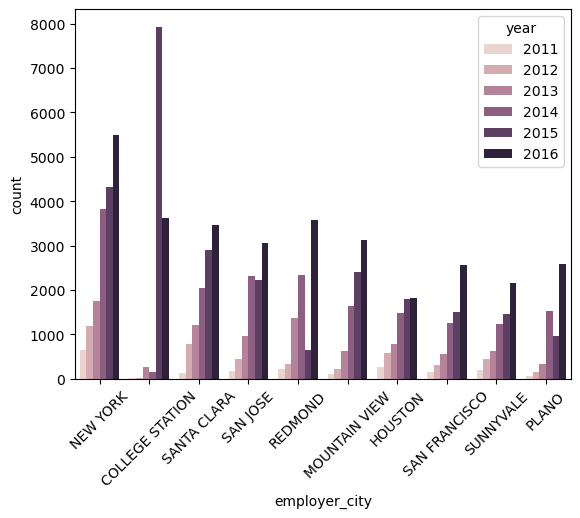

In [156]:
sns.countplot(x = 'employer_city', hue = 'year', data =df, order = df.employer_city.value_counts().iloc[:10].index)
plt.xticks(rotation = 45)
plt.show()

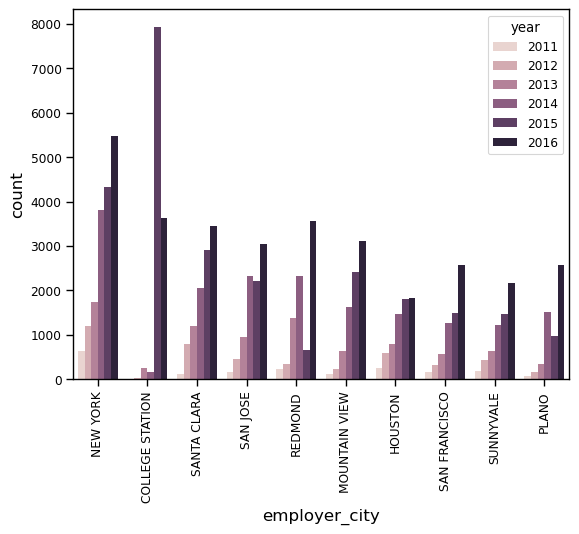

In [159]:
#fig, ax = plt.subplots()
#fig.set_size_inches(13.7, 8.27)
sns.set_context("paper", rc={"font.size":12,"axes.titlesize":12,"axes.labelsize":12})
sns.countplot(x='employer_city', hue='year', data=df, order=df.employer_city.value_counts().iloc[:10].index)
plt.xticks(rotation=90)
ax.set(xlabel='Employer city', ylabel='Number of Visa applications')
plt.show()

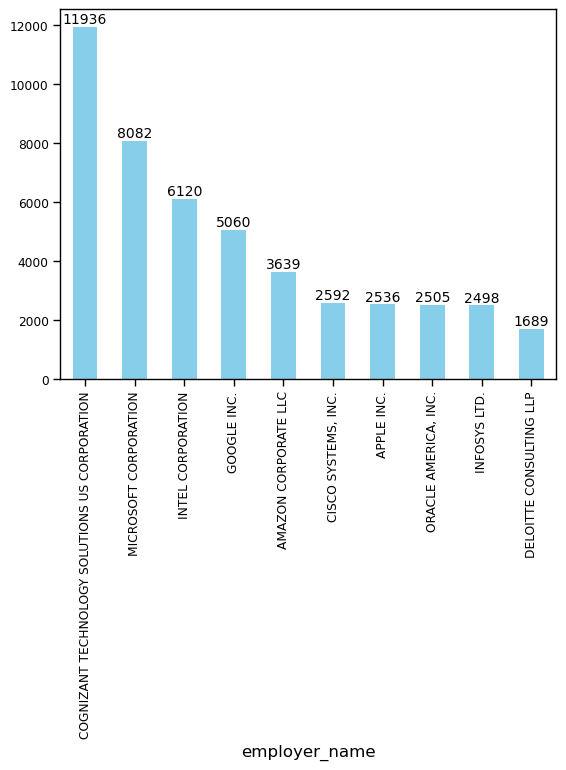

In [165]:
#top 10 employers by visa application
top_emp = df['employer_name'].value_counts().head(10)
top_emp.plot(kind = 'bar', color = 'skyblue')

for i, v in enumerate(top_emp):
    plt.text(i, v+10, str(v), ha = 'center', va = 'bottom', fontsize = 10)
plt.show()

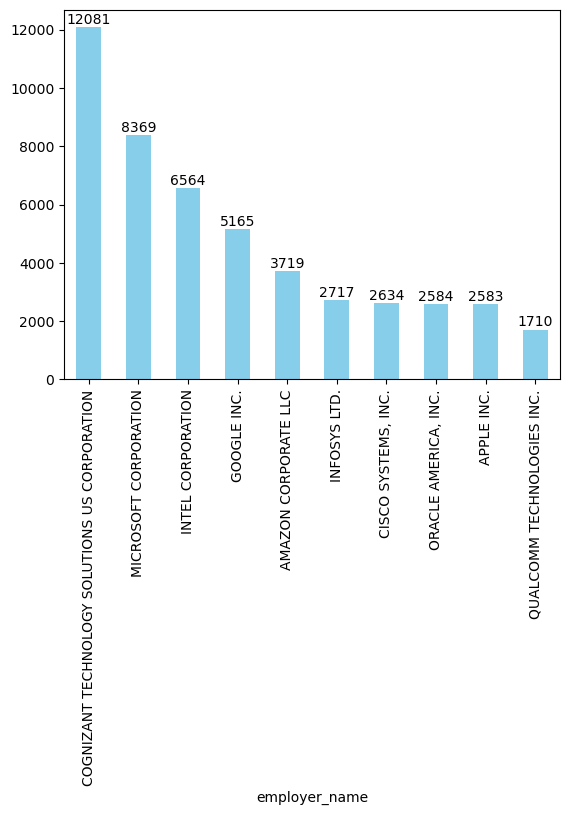

In [4]:
#top 10 employers by visa application
top_emp = df['employer_name'].value_counts().head(10)
top_emp.plot(kind = 'bar', color = 'skyblue')

for i, v in enumerate(top_emp):
    plt.text(i, v+10, str(v), ha = 'center', va = 'bottom', fontsize = 10)
plt.show()

In [166]:
us_economic_counts = {}

for value in df['us_economic_sector'].dropna():
    if value in us_economic_counts:
        us_economic_counts[value] +=1
    else: 
        us_economic_counts[value] = 1

In [167]:
us_economic_counts

{'IT': 49311,
 'Other Economic Sector': 14662,
 'Aerospace': 3917,
 'Advanced Mfg': 17601,
 'Educational Services': 8561,
 'Retail': 4208,
 'Construction': 1315,
 'Hospitality': 1767,
 'Automotive': 1084,
 'Health Care': 6407,
 'Agribusiness': 784,
 'Finance': 8686,
 'Energy': 1021,
 'Transportation': 893,
 'Homeland Security': 78,
 'Biotechnology': 436,
 'Geospatial': 137}

In [168]:
usecollabels = []
usecolvalues = []

explode = (0.035, 0, 0, 0,0,0,0,0,0,0)

for key, value in us_economic_counts.items():
    usecollabels.append(key)
    usecolvalues.append(value)

In [169]:
usecollabels, usecolvalues

(['IT',
  'Other Economic Sector',
  'Aerospace',
  'Advanced Mfg',
  'Educational Services',
  'Retail',
  'Construction',
  'Hospitality',
  'Automotive',
  'Health Care',
  'Agribusiness',
  'Finance',
  'Energy',
  'Transportation',
  'Homeland Security',
  'Biotechnology',
  'Geospatial'],
 [49311,
  14662,
  3917,
  17601,
  8561,
  4208,
  1315,
  1767,
  1084,
  6407,
  784,
  8686,
  1021,
  893,
  78,
  436,
  137])

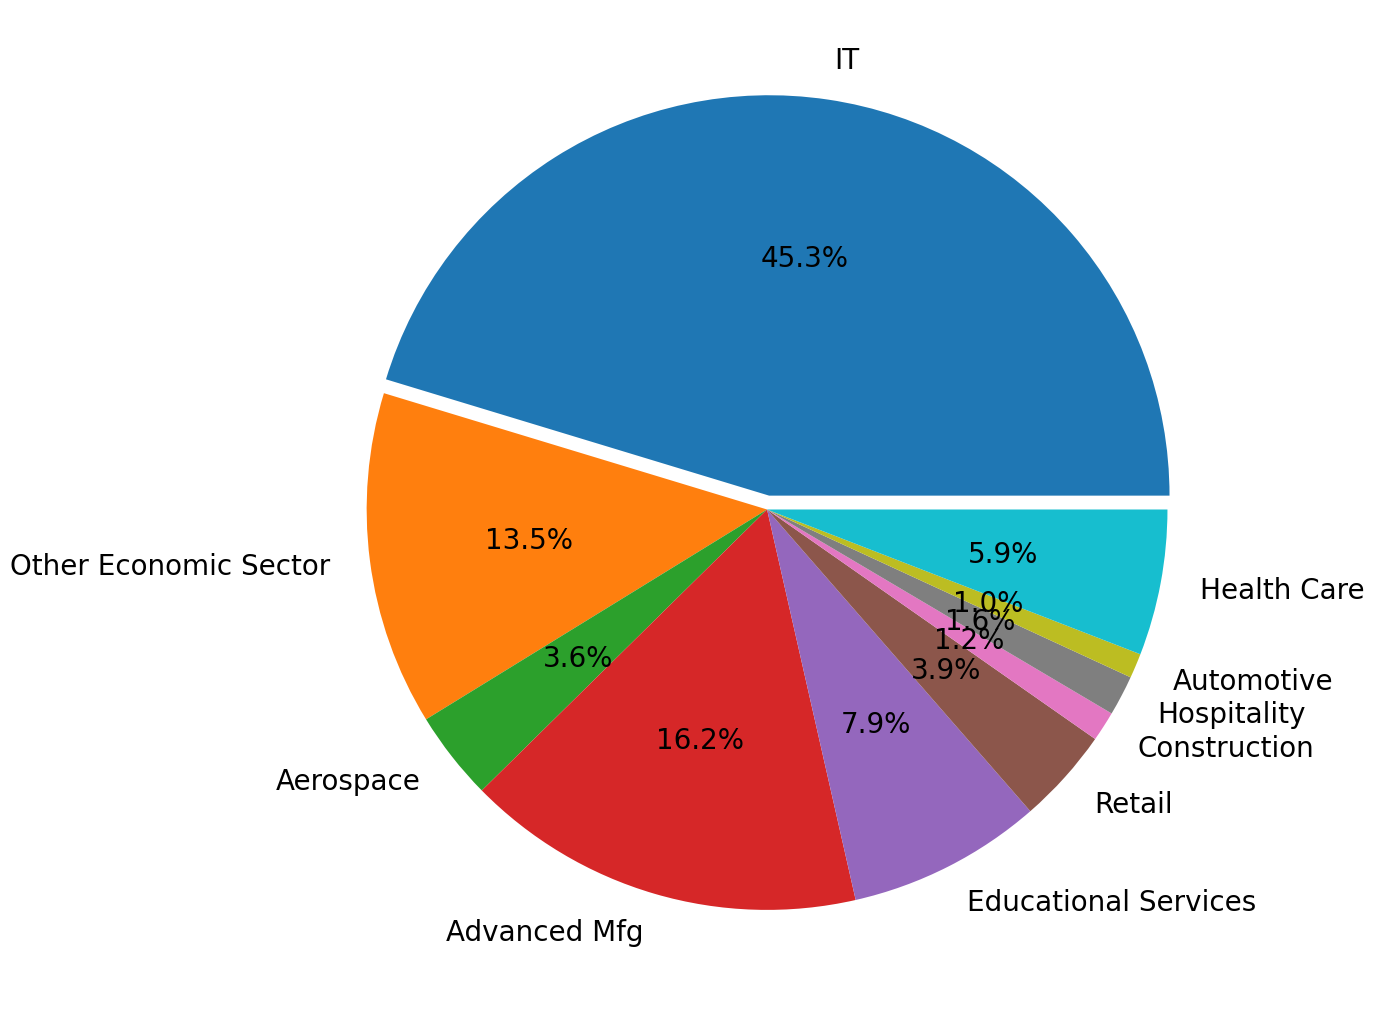

In [174]:
plt.figure(figsize = (13, 13))
plt.pie(usecolvalues[:10], labels = usecollabels[:10], explode = explode, autopct = '%1.1f%%', textprops={"fontsize":20})
plt.show()

In [177]:
df['job_info_job_title'].value_counts()[:20]

job_info_job_title
Software Engineer                   14372
Computer Systems Analyst - V         4747
Senior Software Engineer             3801
Computer Systems Analyst - II        3416
Software Developer                   2880
Assistant Professor                  2604
Programmer Analyst                   2534
Computer Systems Analyst - IV        2496
Systems Analyst                      2034
Software Development Engineer II     1630
Poultry Processing Worker            1594
Component Design Engineer            1064
Poultry Processor                    1037
Business Analyst                      963
software engineer                     932
SOFTWARE ENGINEER                     877
Senior Programmer Analyst             862
Sr. Software Engineer                 847
Senior Software Developer             817
Commercial Cleaner                    802
Name: count, dtype: int64

In [178]:
#Converting values to lower case
df['job_info_job_title'] = df['job_info_job_title'].str.lower()

#Splitting job titles by '-'
df['job_info_job_title'] = df['job_info_job_title'].astype(str).str.split('-').str[0]
#Splitting job titles by 'ii'
df['job_info_job_title'] = df['job_info_job_title'].astype(str).str.split('ii').str[0]
#Splitting job titles by '/'
df['job_info_job_title'] = df['job_info_job_title'].astype(str).str.split('/').str[0]
#Removing leading and ending spaces
df['job_info_job_title'] = df['job_info_job_title'].astype(str).str.strip()
#Replacing "sr." values with "senior"
df['job_info_job_title'] = df['job_info_job_title'].str.replace('sr.', 'senior')
#Replacing "NaN", "NaT" and "nan" values with np.nan
df['job_info_job_title'].replace(["NaN", 'NaT','nan'], np.nan, inplace = True)


df['job_info_job_title'].value_counts(dropna=True)[:10]

C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\1329454539.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['job_info_job_title'].replace(["NaN", 'NaT','nan'], np.nan, inplace = True)


job_info_job_title
software engineer                18582
computer systems analyst         12054
senior software engineer          5802
software developer                4501
programmer analyst                3763
assistant professor               2869
software development engineer     2766
systems analyst                   2587
senior programmer analyst         1884
senior software developer         1625
Name: count, dtype: int64

<Figure size 1270x827 with 0 Axes>

<Figure size 1270x827 with 0 Axes>

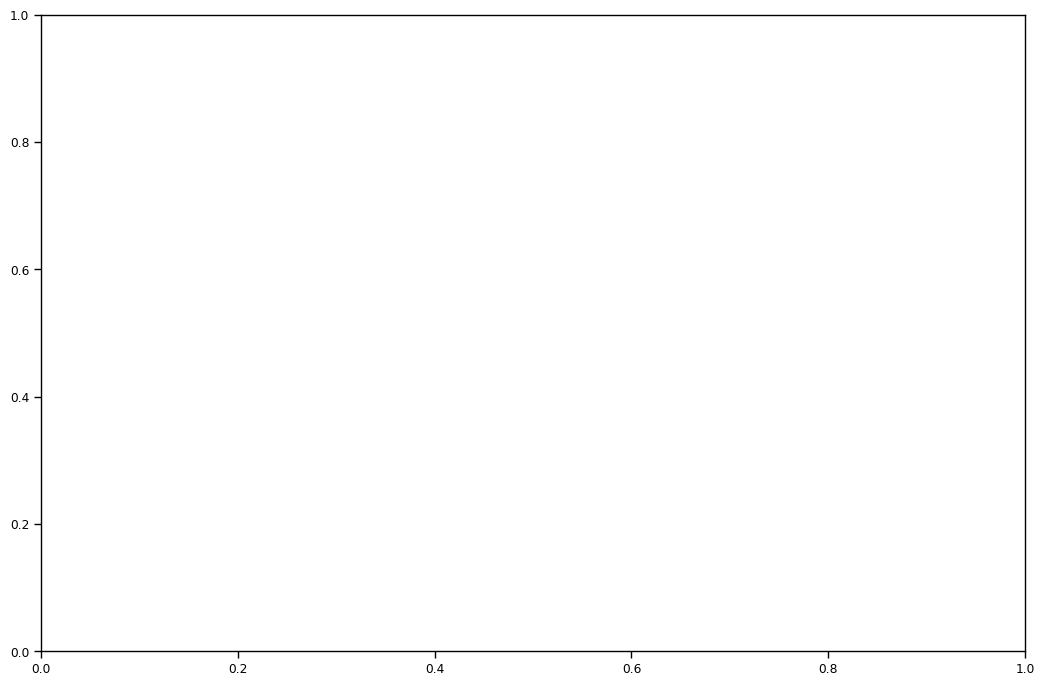

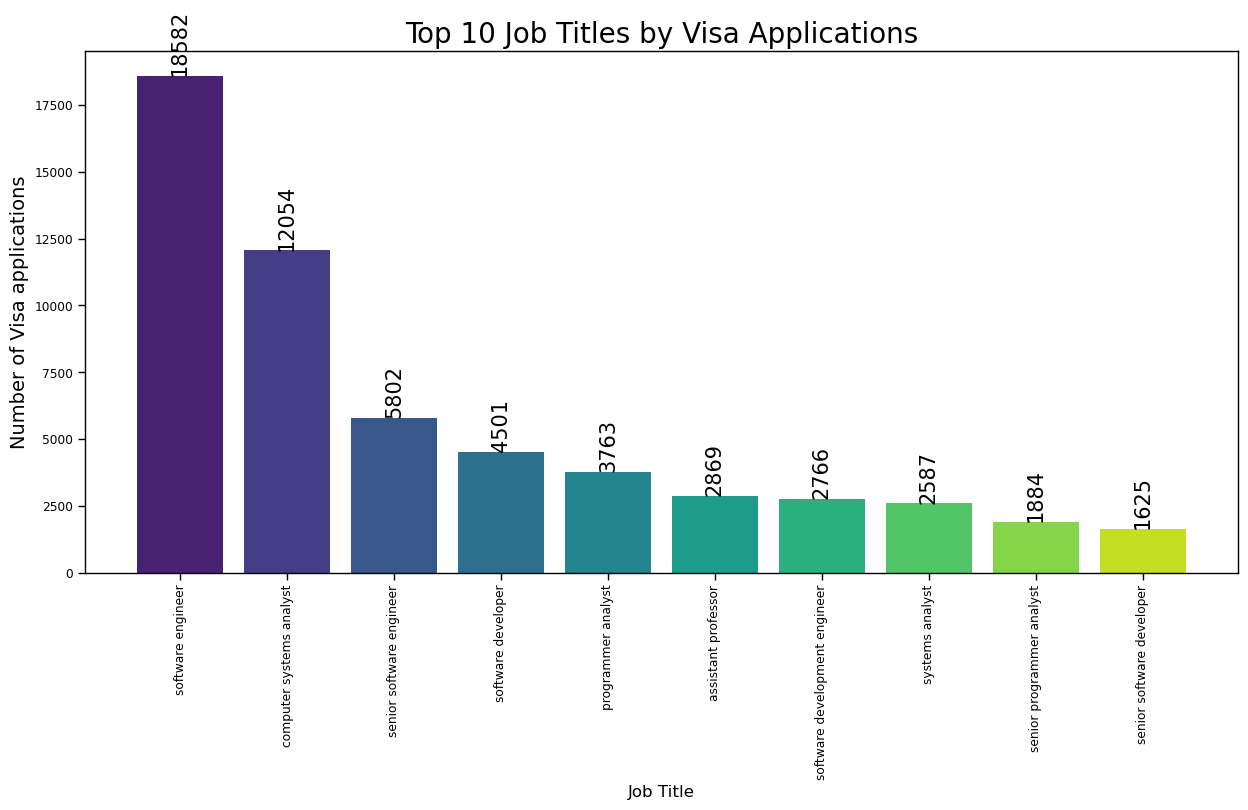

In [ ]:
# Get the top 10 job titles by count
top_job_titles = df['job_info_job_title'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(12.7, 8.27))
sns.set_context(rc={"font.size":14, "axes.labelsize":12})

# Create a bar plot
plt.figure(figsize=(12.7, 8.27))
plt.bar(top_job_titles.index, top_job_titles, color=sns.color_palette("viridis", len(top_job_titles)))

# Add count labels above the bars
for i, v in enumerate(top_job_titles):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontsize=15, rotation=90)

    plt.xlabel('Job Title')
    plt.ylabel('Number of Visa applications', fontsize = 14)
    plt.title('Top 10 Job Titles by Visa Applications',fontsize = 20)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\1798002842.py:9: UserWarning: The palette list has more values (7) than needed (2), which may not be intended.
  sns.countplot(x='country_of_citizenship', hue='case_status', data=df,


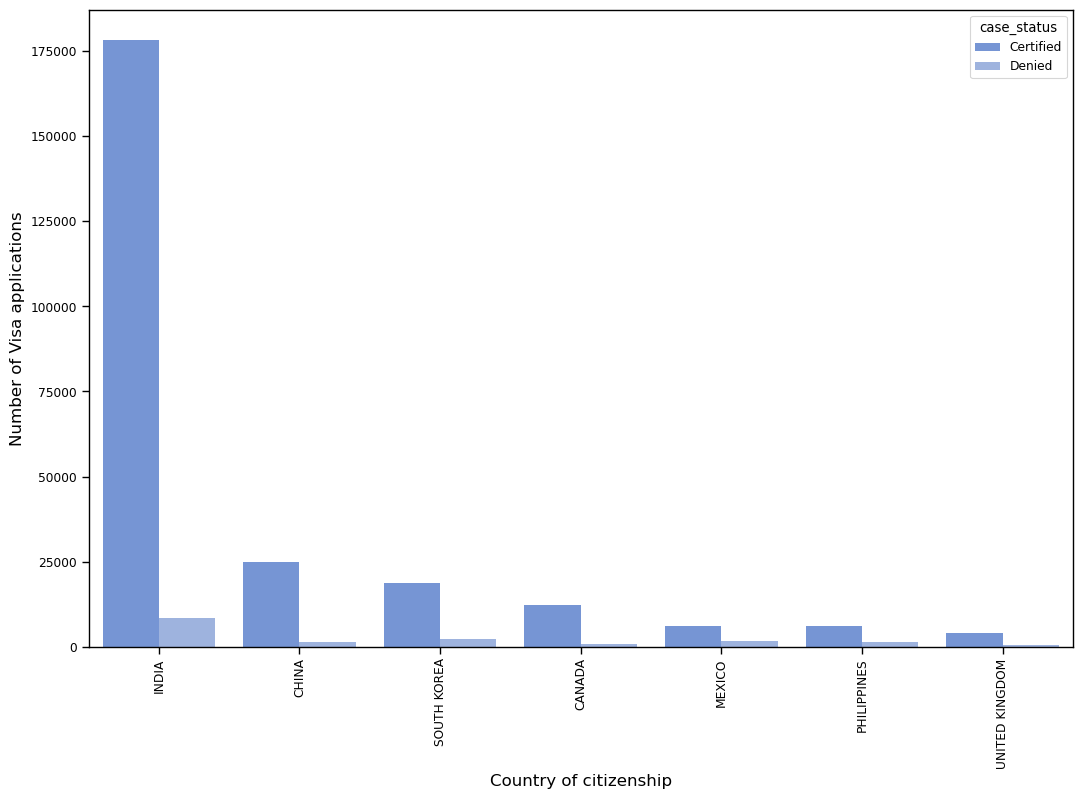

In [197]:
# Convert 'country_of_citizenship' column to categorical data type
df['country_of_citizenship'] = pd.Categorical(df['country_of_citizenship'])

# Setting plot parameters
fig, ax = plt.subplots(figsize=(12.7, 8.27))
sns.set_context(rc={"font.size":14, "axes.labelsize":12})

# Creating the count plot
sns.countplot(x='country_of_citizenship', hue='case_status', data=df,
              palette=sns.diverging_palette(255, 133, l=60, n=7, center="light"),
              order=df.country_of_citizenship.value_counts().iloc[:7].index)

plt.xticks(rotation=90)

# Setting label titles
ax.set(xlabel='Country of citizenship', ylabel='Number of Visa applications')

plt.show()  # This line is necessary to display the plot


C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\4131126318.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='application_type', data=df, palette='GnBu_d', order=df['application_type'].value_counts().index[:10])


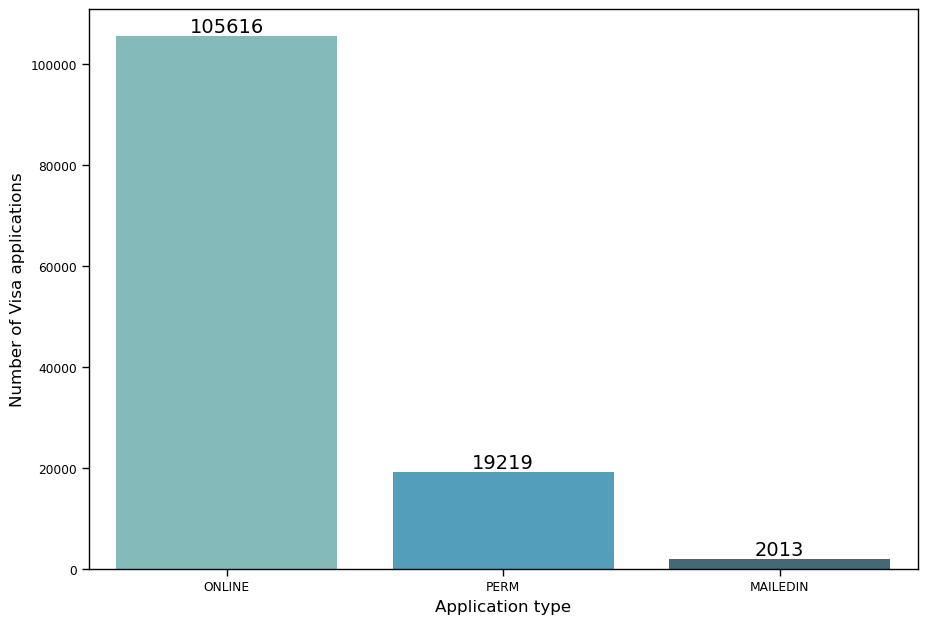

In [198]:
# Setting plot parameters
plt.figure(figsize=(10.7, 7.27))

# Creating the count plot
sns.countplot(x='application_type', data=df, palette='GnBu_d', order=df['application_type'].value_counts().index[:10])

# Iterating over elements in "application_type" column and displaying counts above bars
for i, v in enumerate(df['application_type'].value_counts().head(10)):
    plt.text(i, v, str(v), ha='center', va='bottom')

# Setting labels
plt.xlabel('Application type')
plt.ylabel('Number of Visa applications')
plt.show()

C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\2034061622.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='foreign_worker_info_education', data=df,
C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\2034061622.py:6: UserWarning: The palette list has more values (12) than needed (6), which may not be intended.
  sns.countplot(x='foreign_worker_info_education', data=df,


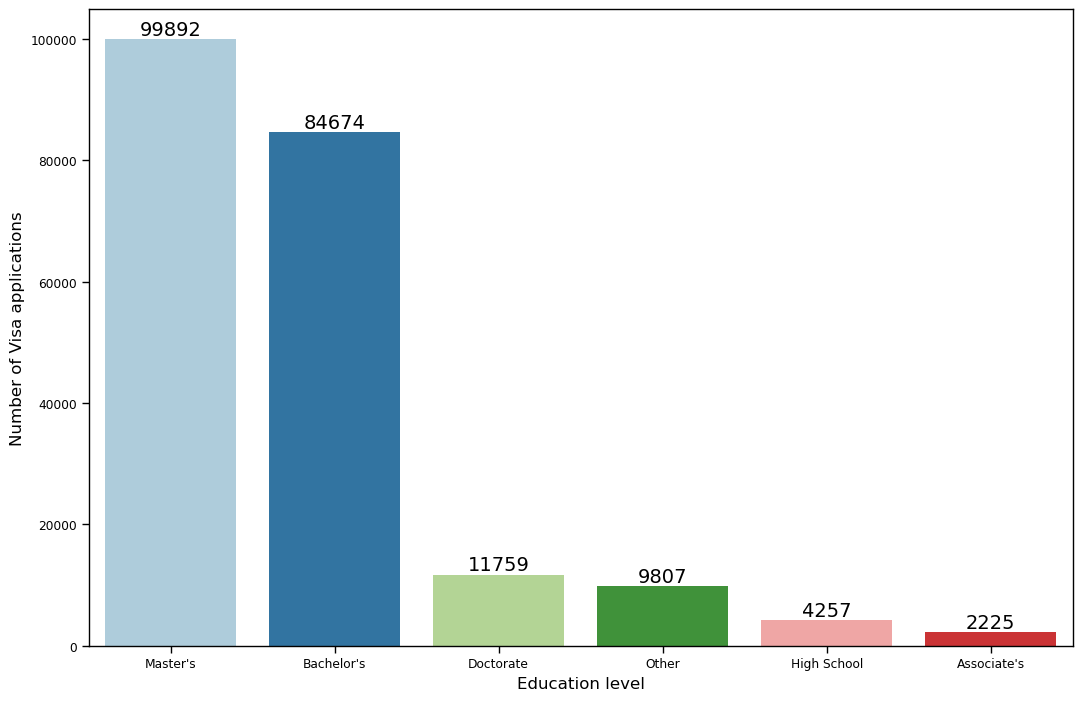

In [199]:
# Setting plot parameters
fig, ax = plt.subplots()
fig.set_size_inches(12.7, 8.27)

# Creating the count plot
sns.countplot(x='foreign_worker_info_education', data=df,
              palette=sns.color_palette("Paired"),
              order=df['foreign_worker_info_education'].value_counts().index[:10])

# Iterating over elements in "foreign_worker_info_education" column and displaying counts above bars
for i, v in enumerate(df['foreign_worker_info_education'].value_counts().head(10)):
    ax.text(i, v, str(v), horizontalalignment='center', verticalalignment='bottom')

# Setting label titles
ax.set(xlabel='Education level', ylabel='Number of Visa applications')
plt.show()


In [209]:
#percentage of non null values

i = 0;
for col in df.columns:
    i = i+1;
    print (i-1,"Column: '{}'".format(col),"contains ", np.round(100*df[col].count()/len(df['case_status']),decimals=2),"% non-null values" )

0 Column: 'add_these_pw_job_title_9089' contains  10.99 % non-null values
1 Column: 'agent_city' contains  56.92 % non-null values
2 Column: 'agent_firm_name' contains  55.74 % non-null values
3 Column: 'agent_state' contains  56.05 % non-null values
4 Column: 'application_type' contains  35.61 % non-null values
5 Column: 'case_received_date' contains  64.39 % non-null values
6 Column: 'case_status' contains  100.0 % non-null values
7 Column: 'class_of_admission' contains  94.08 % non-null values
8 Column: 'country_of_citizenship' contains  94.59 % non-null values
9 Column: 'country_of_citzenship' contains  5.4 % non-null values
10 Column: 'decision_date' contains  100.0 % non-null values
11 Column: 'employer_address_1' contains  99.99 % non-null values
12 Column: 'employer_address_2' contains  33.7 % non-null values
13 Column: 'employer_city' contains  100.0 % non-null values
14 Column: 'employer_country' contains  64.37 % non-null values
15 Column: 'employer_decl_info_title' contains

In [210]:
#keep the columns with non null values count > 33000

df = df.loc[:, df.count()>= 330000]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356168 entries, 0 to 374353
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   case_status             356168 non-null  object        
 1   class_of_admission      335083 non-null  object        
 2   country_of_citizenship  336896 non-null  category      
 3   decision_date           356168 non-null  datetime64[ns]
 4   employer_address_1      356131 non-null  object        
 5   employer_city           356158 non-null  object        
 6   employer_name           356160 non-null  object        
 7   employer_postal_code    356135 non-null  object        
 8   employer_state          356131 non-null  object        
 9   job_info_work_city      356073 non-null  object        
 10  job_info_work_state     356072 non-null  object        
 11  pw_amount_9089          353965 non-null  object        
 12  pw_soc_code             355594 non-

In [212]:
df.columns

Index(['case_status', 'class_of_admission', 'country_of_citizenship',
       'decision_date', 'employer_address_1', 'employer_city', 'employer_name',
       'employer_postal_code', 'employer_state', 'job_info_work_city',
       'job_info_work_state', 'pw_amount_9089', 'pw_soc_code', 'pw_soc_title',
       'pw_source_name_9089', 'pw_unit_of_pay_9089', 'casenumberlist', 'year',
       'month', 'day'],
      dtype='object')

In [214]:
df.loc[df['case_status'] == 'Certified', 'case_status'] =1
df.loc[df['case_status'] == 'Denied', 'case_status'] =0

In [215]:
df['case_status'].unique()

array([1, 0], dtype=object)

In [216]:
df['employer_state'].isnull().sum()

np.int64(37)

In [217]:
df['employer_state'].mode()[0]

'CALIFORNIA'

In [218]:
df['employer_state'] = df['employer_state'].fillna(df['employer_state'].mode()[0])

C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\4165033301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['employer_state'] = df['employer_state'].fillna(df['employer_state'].mode()[0])


In [219]:
df['employer_state'].isnull().sum()

np.int64(0)

In [220]:
#Mapping from state name to abbreviation
state_abbrevs = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY',
    'Northern Mariana Islands':'MP',
    'Palau': 'PW',
    'Puerto Rico': 'PR',
    'Virgin Islands': 'VI',
    'District of Columbia': 'DC'
}

#Capitalizing Keys
us_state_abbrev = {k.upper(): v for k, v in state_abbrevs.items()}
df['employer_state'].replace(us_state_abbrev, inplace=True)
df.employer_state = df.employer_state.astype(str)

C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\1856418359.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['employer_state'].replace(us_state_abbrev, inplace=True)
C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\1856418359.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.employer_state = df.employer_state.astype(str)


In [221]:
df['pw_soc_code'] = df['pw_soc_code'].str.replace('.','')
df['pw_soc_code'] = df['pw_soc_code'].str.replace('-','')
df['pw_soc_code'] = df['pw_soc_code'].astype(str).str[0:6]
df['pw_soc_code'].value_counts()

#Finding "nan" values in "pw_soc_code" column and filling them with mode
df.loc[df['pw_soc_code'] == "nan",'pw_soc_code'] = df['pw_soc_code'].mode()[0]

#Finding "None" values in "pw_soc_code" column and filling them with mode
df.loc[df['pw_soc_code'] == "None",'pw_soc_code'] = df['pw_soc_code'].mode()[0]

#Changing type from string to int
df['pw_soc_code'] = df['pw_soc_code'].astype(int)
df['case_status'] = df['case_status'].astype(int)

C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\2394249466.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pw_soc_code'] = df['pw_soc_code'].str.replace('.','')
C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\2394249466.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pw_soc_code'] = df['pw_soc_code'].str.replace('-','')
C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\2394249466.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

In [222]:
#missing value treatment for other columns

#Replacing missing values with mode
df['class_of_admission']=df['class_of_admission'].fillna((df['class_of_admission'].mode()[0]))
df['country_of_citizenship']=df['country_of_citizenship'].fillna((df['country_of_citizenship'].mode()[0]))
df['employer_city']=df['employer_city'].fillna((df['employer_city'].mode()[0]))
df['employer_name']=df['employer_name'].fillna((df['employer_name'].mode()[0]))
df['employer_name']=df['employer_name'].astype(str).str.upper()
df['pw_source_name_9089']=df['pw_source_name_9089'].fillna((df['pw_source_name_9089'].mode()[0]))

C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\2329607610.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['class_of_admission']=df['class_of_admission'].fillna((df['class_of_admission'].mode()[0]))
C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\2329607610.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['country_of_citizenship']=df['country_of_citizenship'].fillna((df['country_of_citizenship'].mode()[0]))
C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\2329607610.py:6: SettingW

In [223]:
# Convert the column containing numerical values with commas to numeric format
df['pw_amount_9089'] = df['pw_amount_9089'].str.replace(',', '').astype(float)

# Now, you can replace null values in the numerical column with the median
median_pw_amount = df['pw_amount_9089'].median()
df['pw_amount_9089'].fillna(median_pw_amount, inplace=True)

# Verify that there are no more null values
print(df.isnull().sum())

C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\2576784128.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pw_amount_9089'] = df['pw_amount_9089'].str.replace(',', '').astype(float)
C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\2576784128.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on th

case_status                  0
class_of_admission           0
country_of_citizenship       0
decision_date                0
employer_address_1          37
employer_city                0
employer_name                0
employer_postal_code        33
employer_state               0
job_info_work_city          95
job_info_work_state         96
pw_amount_9089               0
pw_soc_code                  0
pw_soc_title              2321
pw_source_name_9089          0
pw_unit_of_pay_9089       1481
casenumberlist               0
year                         0
month                        0
day                          0
dtype: int64


In [224]:
#Indices of selected features for categorcal data to do encoding
chosen_attrs = [0,1,2,5,6,8,12,14,17]
df = df.iloc[:,chosen_attrs]

In [225]:
from sklearn.preprocessing import LabelEncoder
categorical_variables = {}

#Creating categories denoted by integers from column values
for col in df.columns:
    cat_var_name = "cat_"+ col
    cat_var_name = LabelEncoder()
    cat_var_name.fit(df[col])
    df[col] = cat_var_name.transform(df[col])
    categorical_variables[col] = cat_var_name

df.info()

C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\1741249944.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = cat_var_name.transform(df[col])
C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\1741249944.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = cat_var_name.transform(df[col])
C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\1741249944.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

<class 'pandas.core.frame.DataFrame'>
Index: 356168 entries, 0 to 374353
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   case_status             356168 non-null  int64
 1   class_of_admission      356168 non-null  int64
 2   country_of_citizenship  356168 non-null  int64
 3   employer_city           356168 non-null  int64
 4   employer_name           356168 non-null  int64
 5   employer_state          356168 non-null  int64
 6   pw_soc_code             356168 non-null  int64
 7   pw_source_name_9089     356168 non-null  int64
 8   year                    356168 non-null  int64
dtypes: int64(9)
memory usage: 27.2 MB


C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_32400\1741249944.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = cat_var_name.transform(df[col])


In [238]:
x,y = df.iloc[:,0],df.iloc[:,1:-1]

In [235]:
x

0         1
1         0
2         1
3         1
4         1
         ..
374349    1
374350    1
374351    1
374352    1
374353    1
Name: case_status, Length: 356168, dtype: int64

In [239]:
y

,class_of_admission,country_of_citizenship,employer_city,employer_name,employer_state,pw_soc_code,pw_source_name_9089
0,28,79,3506,42973,40,76,3
1,5,79,749,47896,40,592,3
2,19,79,1897,54186,52,122,3
3,5,79,1694,18698,40,511,3
4,31,79,53,2602,40,493,3
...,...,...,...,...,...,...,...
374349,19,79,2190,48352,21,96,3
374350,19,79,3173,55538,41,96,3
374351,31,79,4476,24596,6,93,3
374352,19,79,3506,16913,40,94,4


In [240]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.25, random_state=1)

In [244]:
x_test

115395    1
347575    1
61462     0
254824    1
264842    1
         ..
320968    1
226348    1
98823     1
217093    0
185069    1
Name: case_status, Length: 89042, dtype: int64

In [247]:
y_test

,class_of_admission,country_of_citizenship,employer_city,employer_name,employer_state,pw_soc_code,pw_source_name_9089
115395,19,182,3506,8542,40,191,3
347575,36,163,1174,12985,50,445,3
61462,19,70,2461,47463,46,617,4
254824,5,163,2854,63798,6,154,3
264842,19,79,1601,11763,52,96,3
...,...,...,...,...,...,...,...
320968,31,25,4604,3379,55,97,3
226348,19,79,4468,69276,6,97,3
98823,19,79,3506,65766,40,100,3
217093,12,116,893,11677,18,476,3
